# Eigenvalue analysis of SINOS and D-SINOS


In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.interpolate import BarycentricInterpolator
from scipy.linalg import eigh, solve

from discretization import Discretization
from utils import make_boundary_hhalf_matrix_numpy

In [2]:
mpl.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 15,
        "lines.linewidth": 3,
    }
)

In [3]:
degree = 10

# --- Discretization ---
disc = Discretization((degree, degree))
disc.init_boundary_quadrature()

x, y = disc.x
wx, wy = disc.w

Dx, Dy = disc.nabla
W = disc.W
X_bc = disc.X_bc
W_bc = disc.W_bc

Hmat = disc.Hmat
Hmat_s = disc.Hmat_s

print("degree:", degree)
print("N:", disc.N)

degree: 10
N: 121


In [4]:
# --- Laplacian and H^1 inner-product ---
Dxx = Dx @ Dx
Dxy = Dx @ Dy
Dyy = Dy @ Dy

Lap = Dxx + Dyy

B_H1 = W @ Hmat
B_H1 = 0.5 * (B_H1 + B_H1.T)

In [5]:
# --- Trace matrix ---
Ix = np.eye(len(x))
Iy = np.eye(len(y))

interp_x = BarycentricInterpolator(x, Ix, axis=0)
interp_y = BarycentricInterpolator(y, Iy, axis=0)

trace_x_left = interp_x(-1.0)[None, :]
trace_x_right = interp_x(1.0)[None, :]
trace_y_bottom = interp_y(-1.0)[None, :]
trace_y_top = interp_y(1.0)[None, :]

T_left = np.kron(trace_x_left, Iy)
T_right = np.kron(trace_x_right, Iy)
T_bottom = np.kron(Ix, trace_y_bottom)
T_top = np.kron(Ix, trace_y_top)

T_lr = np.stack([T_left, T_right], axis=1).reshape(-1, disc.N)
T_bt = np.stack([T_bottom, T_top], axis=1).reshape(-1, disc.N)

T_bc = np.vstack([T_lr, T_bt])

In [6]:
# --- Boundary terms ---
W_bc_half = make_boundary_hhalf_matrix_numpy(
    X_bc,
    W_bc,
    boundary_dim=1,
)

A_bc_mse = (T_bc.T @ T_bc) / len(disc.X_bc)
A_bc_l2 = T_bc.T @ disc.W_bc @ T_bc
A_bc_half = T_bc.T @ W_bc_half @ T_bc

In [7]:
# --- PDE residual matrices ---
A_pde_mse = (Lap.T @ Lap) / disc.N
A_pde_l2 = Lap.T @ W @ Lap
A_pde_sinos = Lap.T @ W @ solve(Hmat, Lap)
A_pde_dsinos = Lap.T @ W @ solve(Hmat_s, Lap)

In [8]:
# --- Combined residual matrices ---

# Original formulations
A_mse = A_pde_mse + A_bc_mse
A_l2 = A_pde_l2 + A_bc_l2
A_sinos = A_pde_sinos + A_bc_half
A_dsinos = A_pde_dsinos + A_bc_half

# MSE interior
A_mse_l2   = A_pde_mse + A_bc_l2
A_mse_half = A_pde_mse + A_bc_half

# L2 interior
A_l2_mse   = A_pde_l2 + A_bc_mse
A_l2_half  = A_pde_l2 + A_bc_half

# SINOS interior
A_sinos_mse = A_pde_sinos + A_bc_mse
A_sinos_l2  = A_pde_sinos + A_bc_l2

# D-SINOS interior
A_dsinos_mse = A_pde_dsinos + A_bc_mse
A_dsinos_l2  = A_pde_dsinos + A_bc_l2

In [9]:
# --- Symmetrize matrices ---

# Original formulations
A_mse = 0.5 * (A_mse + A_mse.T)
A_l2 = 0.5 * (A_l2 + A_l2.T)
A_sinos = 0.5 * (A_sinos + A_sinos.T)
A_dsinos = 0.5 * (A_dsinos + A_dsinos.T)

# MSE interior ablations
A_mse_l2 = 0.5 * (A_mse_l2 + A_mse_l2.T)
A_mse_half = 0.5 * (A_mse_half + A_mse_half.T)

# L2 interior ablations
A_l2_mse = 0.5 * (A_l2_mse + A_l2_mse.T)
A_l2_half = 0.5 * (A_l2_half + A_l2_half.T)

# SINOS interior ablations
A_sinos_mse = 0.5 * (A_sinos_mse + A_sinos_mse.T)
A_sinos_l2 = 0.5 * (A_sinos_l2 + A_sinos_l2.T)

# D-SINOS interior ablations
A_dsinos_mse = 0.5 * (A_dsinos_mse + A_dsinos_mse.T)
A_dsinos_l2 = 0.5 * (A_dsinos_l2 + A_dsinos_l2.T)

In [10]:
# --- Eigenvalues relative to H1 ---

# Original formulations
eig_mse = eigh(A_mse, B_H1, eigvals_only=True)
eig_l2 = eigh(A_l2, B_H1, eigvals_only=True)
eig_sinos = eigh(A_sinos, B_H1, eigvals_only=True)
eig_dsinos = eigh(A_dsinos, B_H1, eigvals_only=True)

# MSE interior ablations
eig_mse_l2 = eigh(A_mse_l2, B_H1, eigvals_only=True)
eig_mse_half = eigh(A_mse_half, B_H1, eigvals_only=True)

# L2 interior ablations
eig_l2_mse = eigh(A_l2_mse, B_H1, eigvals_only=True)
eig_l2_half = eigh(A_l2_half, B_H1, eigvals_only=True)

# SINOS interior ablations
eig_sinos_mse = eigh(A_sinos_mse, B_H1, eigvals_only=True)
eig_sinos_l2 = eigh(A_sinos_l2, B_H1, eigvals_only=True)

# D-SINOS interior ablations
eig_dsinos_mse = eigh(A_dsinos_mse, B_H1, eigvals_only=True)
eig_dsinos_l2 = eigh(A_dsinos_l2, B_H1, eigvals_only=True)

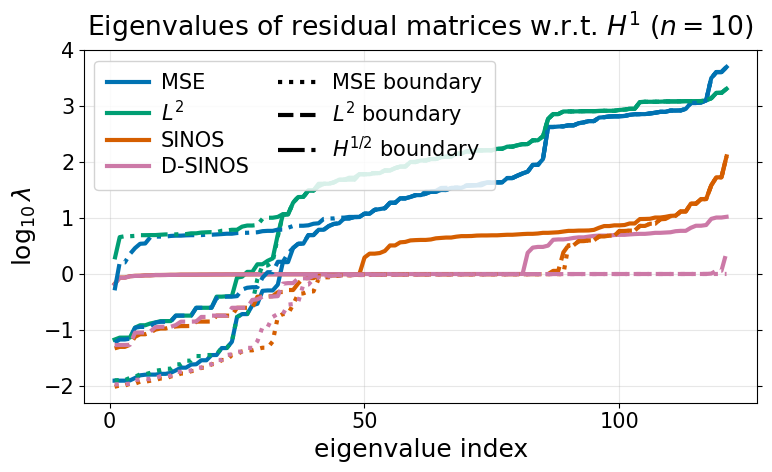

In [11]:
# --- Plotting eigenvalues ---
plt.style.use("seaborn-v0_8-colorblind")
plt.figure(figsize=(8, 5))

x = np.arange(1, disc.N + 1)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
c_mse, c_l2, c_sinos, c_dsinos = colors[:4]

linewidth = 3.0

# Original formulations: solid foreground lines
plt.plot(
    x,
    np.log10(eig_mse),
    color=c_mse,
    linewidth=linewidth,
    label="MSE",
)

plt.plot(
    x,
    np.log10(eig_l2),
    color=c_l2,
    linewidth=linewidth,
    label=r"$L^2$",
)

plt.plot(
    x,
    np.log10(eig_sinos),
    color=c_sinos,
    linewidth=linewidth,
    label="SINOS",
)

plt.plot(
    x,
    np.log10(eig_dsinos),
    color=c_dsinos,
    linewidth=linewidth,
    label="D-SINOS",
)

# Boundary-norm ablations: faint background lines
# MSE interior
plt.plot(
    x,
    np.log10(eig_mse_l2),
    "--",
    color=c_mse,
    linewidth=linewidth,
    label=r"$L^2$ boundary",
)
plt.plot(
    x,
    np.log10(eig_mse_half),
    "-.",
    color=c_mse,
    linewidth=linewidth,
    label=r"$H^{1/2}$ boundary",
)

# L2 interior
plt.plot(
    x,
    np.log10(eig_l2_mse),
    ":",
    color=c_l2,
    linewidth=linewidth,
    label="MSE boundary",
)
plt.plot(
    x,
    np.log10(eig_l2_half),
    "-.",
    color=c_l2,
    linewidth=linewidth,
)

# SINOS interior
plt.plot(
    x,
    np.log10(eig_sinos_mse),
    ":",
    color=c_sinos,
    linewidth=linewidth,
)
plt.plot(
    x,
    np.log10(eig_sinos_l2),
    "--",
    color=c_sinos,
    linewidth=linewidth,
)

# D-SINOS interior
plt.plot(
    x,
    np.log10(eig_dsinos_mse),
    ":",
    color=c_dsinos,
    linewidth=linewidth,
)
plt.plot(
    x,
    np.log10(eig_dsinos_l2),
    "--",
    color=c_dsinos,
    linewidth=linewidth,
)

plt.title(rf"Eigenvalues of residual matrices w.r.t. $H^1$ ($n={degree}$)", pad=10)
plt.xlabel("eigenvalue index")
plt.ylabel(r"$\log_{10}\lambda$")
plt.xticks(np.arange(0, 121, step=50))
plt.yticks(np.arange(-2, 5, step=1))
ax = plt.gca()
ax.tick_params(axis="y", which="both", left=True, right=True)

handles, labels = ax.get_legend_handles_labels()

order = [0, 1, 2, 3, 6, 4, 5]

legend = ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="upper left",
    ncol=2,
    columnspacing=1.4,
    handlelength=2.0,
    handletextpad=0.6,
    labelspacing=0.3,
    borderpad=0.6,
    frameon=True,
    framealpha=0.85,
)

# Boundary-norm entries: neutral black in the legend
for handle in legend.legend_handles[4:]:
    handle.set_color("black")
    
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"media/eigenvalues_n{degree}.pdf", bbox_inches="tight")
plt.show()

In [12]:
# --- Stiffness ratios ---
C0_mse = eig_mse[0]
C1_mse = eig_mse[-1]

C0_l2 = eig_l2[0]
C1_l2 = eig_l2[-1]

C0_sinos = eig_sinos[0]
C1_sinos = eig_sinos[-1]

C0_dsinos = eig_dsinos[0]
C1_dsinos = eig_dsinos[-1]

pd.DataFrame({
    "method": ["MSE", "L2", "SINOS", "D-SINOS"],
    "C0": [C0_mse, C0_l2, C0_sinos, C0_dsinos],
    "C1": [C1_mse, C1_l2, C1_sinos, C1_dsinos],
    "C1/C0": [C1_mse / C0_mse, C1_l2 / C0_l2, C1_sinos / C0_sinos, C1_dsinos / C0_dsinos],
})

,method,C0,C1,C1/C0
0,MSE,0.012283,5043.026166,410578.034455
1,L2,0.066740,2052.822084,30758.667198
2,SINOS,0.662579,126.821136,191.405394
3,D-SINOS,0.655217,10.509930,16.040386
